# Problem Introduction

In hockey analytics, not all shots are created equal. A shot from the slot directly in front of the net is far more dangerous than a low-percentage attempt from the blue line. Quantifying that difference is the foundation of expected goals (xG) modeling.

The goal of this project is to predict the probability that a given NHL shot results in a goal using play-by-play event data and shot coordinates. More specifically, I want to explore whether deep learning models that operate on spatial representations of shot location can outperform traditional expected goals approaches based on engineered features like distance and angle.

This problem is interesting for two reasons. First, it is inherently spatial: scoring probability depends strongly on geometric relationships between the puck and the net. Second, it allows for a clean comparison between classical statistical models and convolutional neural networks, making it a good test case for understanding when deep learning meaningfully adds value.

The core question I aim to answer is:

Does explicitly modeling spatial structure with a convolutional neural network improve goal prediction performance compared to traditional tabular approaches?

By evaluating logistic regression, a multilayer perceptron, and a spatial CNN under the same temporal train/test split, I aim to compare not just performance, but also the impact of representation choice on model effectiveness.

Github link: https://github.com/niliacklein33/Deep-Learning-Final-NHL-Goal-Prediction

## The Data

The dataset used in this analysis was obtained from Kaggle and contains cleaned NHL shot-level data from the 2020–2021 through 2024–2025 seasons, including event type, coordinates, period information, and player identifiers.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/samuarg/nhl-clean-shots-data-2020-2021-to-2024-2025/nhl_shots_data.csv


In [3]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


2026-03-01 19:12:50.208783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772392370.430089      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772392370.486255      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772392370.922435      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772392370.922476      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772392370.922478      55 computation_placer.cc:177] computation placer alr

# Exploratory Data Analysis

**Dataset Overview**

The dataset consists of shot-level NHL event data from the 2020–2021 through 2024–2025 seasons, obtained from Kaggle. Each row represents a shot attempt and includes features such as:

Event type (goal, shot-on-goal, missed-shot)

Shot coordinates (xCoord, yCoord)

Period and time remaining

Shooting player and goalie identifiers

Team identifiers

Home team defending side

After filtering to shot attempts only (goal, shot-on-goal, missed-shot), the dataset contains over 500,000 observations. The target variable is binary, indicating whether the shot resulted in a goal.

The goal rate is approximately 7%, indicating significant class imbalance.

**Target Distribution**

A frequency analysis of eventType shows:

* ~334k shot-on-goal
* ~155k missed-shot
* ~38k goals

This confirms strong imbalance (~7% positive class). Because of this imbalance, precision–recall metrics are more appropriate than accuracy for evaluation.

No further class balancing was performed at the data level; instead, class weighting was incorporated into the loss function during model training.

**Spatial Distribution**

Shot coordinates range approximately:

* xCoord: -100 to +100
* yCoord: -42.5 to +42.5

To ensure spatial consistency, shot coordinates were normalized such that all shots attack toward the same goal. This transformation was necessary so that spatial models (CNNs) could learn consistent geometric patterns rather than team-dependent orientations.

A scatter plot of normalized shot locations shows:

* High density near the offensive zone
* Concentration of attempts in the slot region
* Sparse distribution in defensive zone

This supports the hypothesis that shot location strongly influences scoring probability.

**Feature Distributions**
Shot Distance

Distance from the net shows a right-skewed distribution, with most shots occurring between 20–60 feet from goal. Very long-distance shots are less frequent.

Shot Angle

Shot angle is concentrated near smaller values (more central shots), with larger angles corresponding to wider shooting positions. The distribution suggests that central shooting lanes are more common.

Because distance and angle are measured on different scales, standardization was applied before training logistic regression and MLP models.

**Correlation Analysis**

Distance and angle are moderately correlated but not redundant. Both features independently influence scoring probability:

Closer distance increases goal likelihood.

Smaller shooting angle (more central) increases goal likelihood.

No extreme multicollinearity was observed between engineered features.

**Data Cleaning**

The following cleaning steps were performed:

* Removed rows with missing coordinate values.
* Filtered to relevant shot event types.
* Removed coordinates outside rink bounds.
* Normalized shot direction to ensure consistent attacking orientation.
* Created a binary target variable (label_goal).

No imputation was required, as missingness was minimal in relevant features.

**Transformations and Modeling Implications**

Because of:

* Class imbalance
* Differing feature scales
* Strong spatial structure

The following modeling considerations were made:

* Used class-weighted loss for neural networks.
* Standardized features for logistic regression and MLP.
* Constructed structured spatial input for CNN modeling.

These preprocessing decisions were guided by the observed feature distributions and dataset imbalance.

In [4]:

csv_path = "/kaggle/input/datasets/samuarg/nhl-clean-shots-data-2020-2021-to-2024-2025/nhl_shots_data.csv"

df = pd.read_csv(csv_path)

print(df.shape)
display(df.head())

(528720, 19)


,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,homeTeamDefendingSide,zoneCode,xCoord,yCoord,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder
0,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:52,right,O,56,-39,wrist,8483495.0,8480045.0,1,13
1,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,19:31,right,O,71,-28,wrist,8479407.0,8480045.0,1,21
2,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:20,right,O,47,-23,slap,8476462.0,8480045.0,1,24
3,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,18:58,right,O,-40,-30,wrist,8482175.0,8474593.0,7,31
4,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,18:54,right,O,-36,15,slap,8482671.0,8474593.0,7,36


In [5]:
df.columns
df["eventType"].value_counts().head(10)

eventType
shot-on-goal    334821
missed-shot     155537
goal             38362
Name: count, dtype: int64

In [6]:
#Clean up events
# Keep only relevant shot attempts
shot_events = ["goal", "shot-on-goal", "missed-shot"]
shots = df[df["eventType"].isin(shot_events)].copy()

# Binary label
shots["label_goal"] = (shots["eventType"] == "goal").astype(int)

print("Total shots:", len(shots))
print("Goal rate:", shots["label_goal"].mean())
shots["eventType"].value_counts()

Total shots: 528720
Goal rate: 0.07255636253593585


eventType
shot-on-goal    334821
missed-shot     155537
goal             38362
Name: count, dtype: int64

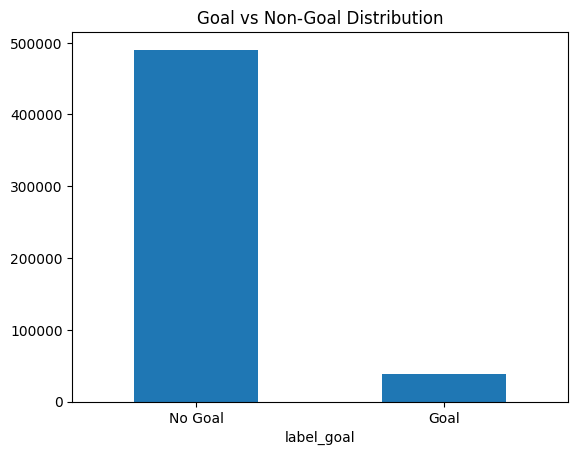

In [30]:
#Check Target distribution
shots["label_goal"].value_counts().plot(kind="bar")
plt.title("Goal vs Non-Goal Distribution")
plt.xticks([0,1], ["No Goal", "Goal"], rotation=0)
plt.show()

In [7]:
#Normalize attack direction

# Identify if shooting team is home
is_home_shot = shots["eventOwnerTeamId"] == shots["homeTeamId"]

home_def_right = shots["homeTeamDefendingSide"].str.lower() == "right"
home_def_left  = shots["homeTeamDefendingSide"].str.lower() == "left"

# Flip logic
flip = (is_home_shot & home_def_right) | (~is_home_shot & home_def_left)

shots["x_att"] = shots["xCoord"].astype(float)
shots["y_att"] = shots["yCoord"].astype(float)

shots.loc[flip, "x_att"] *= -1
shots.loc[flip, "y_att"] *= -1

print("Fraction attacking positive x:", (shots["x_att"] > 0).mean())


Fraction attacking positive x: 0.9771429111817219


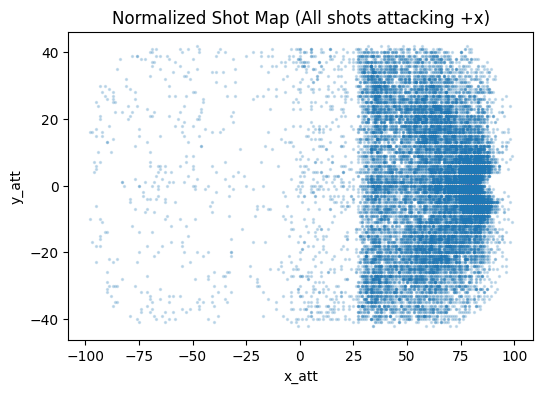

In [7]:
#quick check 
sample = shots.sample(20000, random_state=42)

plt.figure(figsize=(6,4))
plt.scatter(sample["x_att"], sample["y_att"], s=2, alpha=0.2)
plt.title("Normalized Shot Map (All shots attacking +x)")
plt.xlabel("x_att")
plt.ylabel("y_att")
plt.show()

/tmp/ipykernel_55/2503616834.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  goal_by_dist = shots.groupby("distance_bin")["label_goal"].mean()


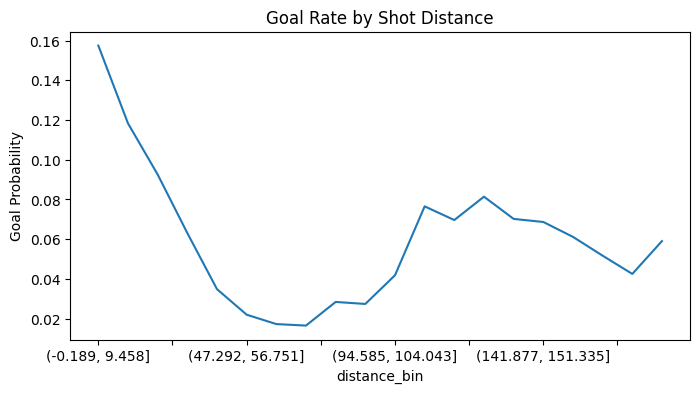

In [27]:
#Goal rate by distance
shots["distance_bin"] = pd.cut(shots["shot_distance"], bins=20)

goal_by_dist = shots.groupby("distance_bin")["label_goal"].mean()

goal_by_dist.plot(kind="line", figsize=(8,4))
plt.title("Goal Rate by Shot Distance")
plt.ylabel("Goal Probability")
plt.show()

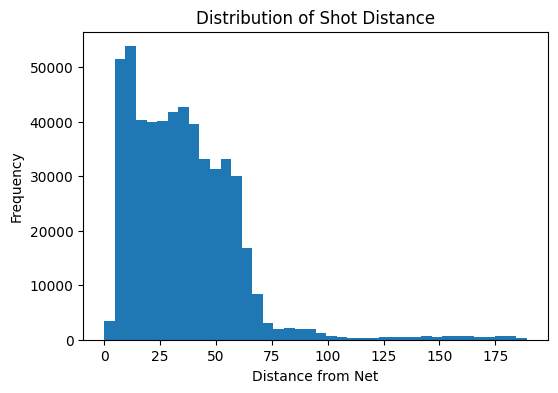

In [31]:
#Shot distance histrogram
plt.figure(figsize=(6,4))
plt.hist(shots["shot_distance"], bins=40)
plt.title("Distribution of Shot Distance")
plt.xlabel("Distance from Net")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_55/2089382032.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  goal_by_angle = shots.groupby("angle_bin")["label_goal"].mean()


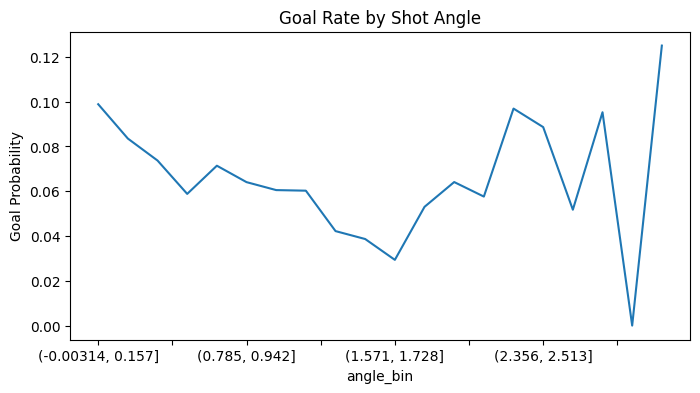

In [28]:
#Goal rate by angle
shots["angle_bin"] = pd.cut(shots["shot_angle"], bins=20)

goal_by_angle = shots.groupby("angle_bin")["label_goal"].mean()

goal_by_angle.plot(kind="line", figsize=(8,4))
plt.title("Goal Rate by Shot Angle")
plt.ylabel("Goal Probability")
plt.show()

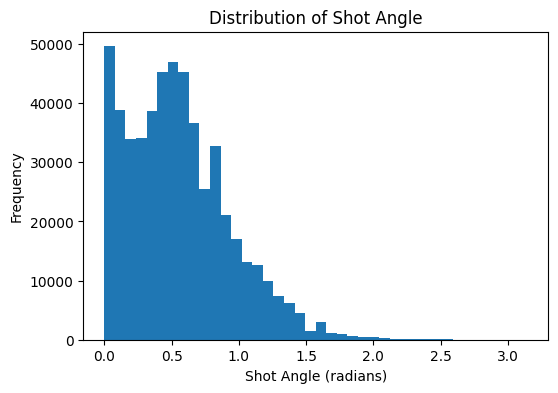

In [32]:
#shot angle histogram
plt.figure(figsize=(6,4))
plt.hist(shots["shot_angle"], bins=40)
plt.title("Distribution of Shot Angle")
plt.xlabel("Shot Angle (radians)")
plt.ylabel("Frequency")
plt.show()

<Figure size 600x400 with 0 Axes>

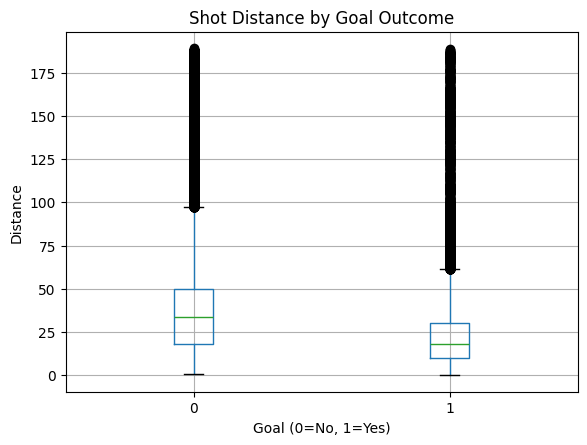

In [33]:
#box plot distance by goal outcome
plt.figure(figsize=(6,4))
shots.boxplot(column="shot_distance", by="label_goal")
plt.title("Shot Distance by Goal Outcome")
plt.suptitle("")
plt.xlabel("Goal (0=No, 1=Yes)")
plt.ylabel("Distance")
plt.show()

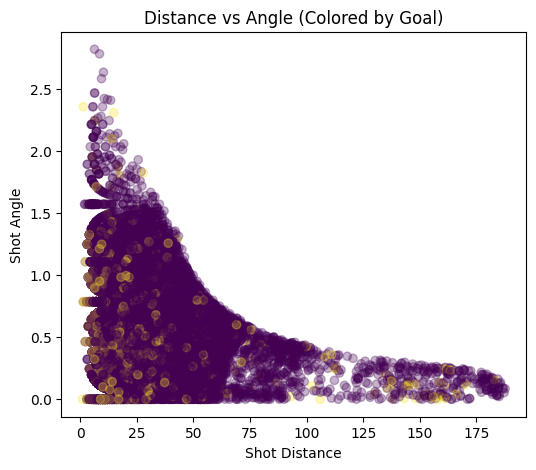

In [34]:
#scatter plot distance v angle

sample = shots.sample(20000, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(sample["shot_distance"],
            sample["shot_angle"],
            c=sample["label_goal"],
            alpha=0.3)
plt.xlabel("Shot Distance")
plt.ylabel("Shot Angle")
plt.title("Distance vs Angle (Colored by Goal)")
plt.show()

In [29]:
#correlation matrix

shots[["shot_distance","shot_angle"]].corr()

,shot_distance,shot_angle
shot_distance,1.000000,-0.247371
shot_angle,-0.247371,1.000000


# Model Comparisons

I tested 3 models: 

* Logistic regression baseline (classic xG style)
* Tabular MLP
* Then spatial CNN

After each model, I provided an explnation

In [36]:
# Define attacking net location (after flipping, net is at +x)
NET_X, NET_Y = 89.0, 0.0

dx = NET_X - shots["x_att"]
dy = NET_Y - shots["y_att"]

shots["shot_distance"] = np.sqrt(dx**2 + dy**2)
shots["shot_angle"] = np.abs(np.arctan2(dy, dx))  # radians

shots[["shot_distance","shot_angle"]].describe()

,shot_distance,shot_angle
count,528720.000000,528720.000000
mean,35.480138,0.552584
std,24.723163,0.380685
min,0.000000,0.000000
25%,16.970563,0.257324
50%,32.249031,0.513252
75%,48.826222,0.785398
max,189.169236,3.141593


In [37]:
#Time-based train/test split
# Use most recent season as test set
train_df = shots[shots["season"] < 20242025].copy()
test_df  = shots[shots["season"] == 20242025].copy()

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

print("Train goal rate:", train_df["label_goal"].mean())
print("Test goal rate:", test_df["label_goal"].mean())

Train size: (415975, 26)
Test size: (112745, 26)
Train goal rate: 0.07282168399543242
Test goal rate: 0.07157745354561178


## Logistic Regression

In [38]:
#Logistic regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

feature_cols = ["shot_distance", "shot_angle"]

X_train = train_df[feature_cols]
y_train = train_df["label_goal"].values

X_test = test_df[feature_cols]
y_test = test_df["label_goal"].values

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced"))
])

lr.fit(X_train, y_train)
p_lr = lr.predict_proba(X_test)[:,1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, p_lr))
print("Logistic Regression PR-AUC:", average_precision_score(y_test, p_lr))

Logistic Regression ROC-AUC: 0.7091747590716412
Logistic Regression PR-AUC: 0.1427307855502083


**Interpretation: Logistic Regression**

I first trained a logistic regression model using engineered features (shot distance and shot angle). Logistic regression assumes a linear relationship between the features and the log-odds of the outcome.

This model performed surprisingly well (ROC-AUC ≈ 0.71), which suggests that distance and angle already capture much of the signal in goal probability.

This makes sense from a hockey perspective:

* Goals are much more likely from closer distances.
* Central shooting angles are more dangerous.
* The relationship is mostly monotonic.

However, logistic regression has clear limitations:

* It cannot capture nonlinear spatial effects.
* It cannot model interactions between regions of the ice.
* It treats the rink as feature space, not as geometry.

So while it performs reasonably well, it cannot fully represent the spatial structure of shot data.

## Multi-layer Perception

In [19]:
#MLP
#Does depth alone improve performance or does spatial representation matter?

# Scale features properly
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

mlp = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

mlp.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)

history_mlp = mlp.fit(
    X_train_s,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=4096,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

p_mlp = mlp.predict(X_test_s).ravel()

print("MLP ROC-AUC:", roc_auc_score(y_test, p_mlp))
print("MLP PR-AUC:", average_precision_score(y_test, p_mlp))


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - auc: 0.5004 - loss: 0.6338 - val_auc: 0.4123 - val_loss: 0.3317
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.4785 - loss: 0.3090 - val_auc: 0.6113 - val_loss: 0.2645
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6110 - loss: 0.2673 - val_auc: 0.6748 - val_loss: 0.2554
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6569 - loss: 0.2608 - val_auc: 0.6928 - val_loss: 0.2516
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6646 - loss: 0.2590 - val_auc: 0.7043 - val_loss: 0.2488
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6742 - loss: 0.2547 - val_auc: 0.7100 - val_loss: 0.2470
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6815 - loss: 0.2510 - val_auc: 0.7122 - val_loss: 0.2458
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6839 - loss: 0.2504 - val_auc: 0.7124 - val_loss: 0.2450
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6823 - loss:

## Interpretation: MLP (Multi-Layer Perceptron)

The MLP adds nonlinear capacity compared to logistic regression. It can model interactions between distance and angle and learn more flexible decision boundaries.

The performance improved slightly (ROC-AUC ≈ 0.7096) over logistic regression (ROC-AUC ≈ 0.7091), indicating that there is some nonlinear structure in the data.

However, the improvement was modest.

This is likely because:

* The feature space is still limited to engineered summary variables.
* Distance and angle already compress most of the spatial information.
* The MLP does not explicitly exploit 2D spatial structure.

The MLP may overfit more easily than logistic regression due to higher model capacity, so regularization and early stopping were important.

## CNN

In [11]:
#Build spatial cnn

#Rasterize Shots Into Image Grid

# Grid resolution
W, H = 100, 42

X_MIN, X_MAX = 0, 100
Y_MIN, Y_MAX = -42.5, 42.5

def shot_to_grid(x, y, w=W, h=H):
    xi = ((x - X_MIN) / (X_MAX - X_MIN) * (w - 1)).astype(int)
    yi = ((y - Y_MIN) / (Y_MAX - Y_MIN) * (h - 1)).astype(int)
    xi = np.clip(xi, 0, w-1)
    yi = np.clip(yi, 0, h-1)
    return xi, yi

def build_images(df):
    imgs = np.zeros((len(df), H, W, 1), dtype=np.float32)
    xi, yi = shot_to_grid(df["x_att"].values, df["y_att"].values)
    imgs[np.arange(len(df)), yi, xi, 0] = 1.0
    return imgs

Ximg_train = build_images(train_df)
Ximg_test = build_images(test_df)

y_train = train_df["label_goal"].values.astype(np.float32)
y_test = test_df["label_goal"].values.astype(np.float32)

print(Ximg_train.shape, Ximg_test.shape)

(415975, 42, 100, 1) (112745, 42, 100, 1)


In [12]:
#Handle class imbalance

pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = neg / pos

print("Positive weight:", pos_weight)

def weighted_bce(pos_weight):
    def loss(y_true, y_pred):
        bce = keras.backend.binary_crossentropy(y_true, y_pred)
        w = y_true * pos_weight + (1 - y_true)
        return keras.backend.mean(w * bce)
    return loss

Positive weight: 12.732174


In [16]:
# CNN Model

cnn = keras.Sequential([
    layers.Input(shape=(H, W, 1)),
    
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=weighted_bce(pos_weight),
    metrics=[keras.metrics.AUC(name="auc")]
)

history_cnn = cnn.fit(
    Ximg_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=4096,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

p_cnn = cnn.predict(Ximg_test).ravel()

print("CNN ROC-AUC:", roc_auc_score(y_test, p_cnn))
print("CNN PR-AUC:", average_precision_score(y_test, p_cnn))

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 686s 8s/step - auc: 0.5061 - loss: 1.2854 - val_auc: 0.5663 - val_loss: 1.2839
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 669s 8s/step - auc: 0.5444 - loss: 1.2786 - val_auc: 0.5833 - val_loss: 1.2777
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 699s 9s/step - auc: 0.5548 - loss: 1.2791 - val_auc: 0.5852 - val_loss: 1.2711
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 664s 8s/step - auc: 0.5644 - loss: 1.2663 - val_auc: 0.5871 - val_loss: 1.2630
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 692s 8s/step - auc: 0.5702 - loss: 1.2654 - val_auc: 0.5860 - val_loss: 1.2579
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 692s 8s/step - auc: 0.5769 - loss: 1.2677 - val_auc: 0.5888 - val_loss: 1.2553
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 663s 8s/step - auc: 0.5813 - loss: 1.2611 - val_auc: 0.5921 - val_loss: 1.2531
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 667s 8s/step - auc: 0.5804 - loss: 1.2584 - val_auc: 0.5937 - val_loss: 1.2516
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 680s 8s/step - auc: 0.5865

## Interpretaion: Initial CNN (Single-Channel Spatial Grid)

This CNN model was built using a single-channel spatial grid representation of shot locations. Each grid cell represented shot frequency (or goal frequency) within that region of the rink.

While this model achieved reasonable performance (ROC-AUC ≈ 0.66), it underperformed compared to logistic regression and the MLP.

This suggests that the initial spatial encoding did not provide enough structured information for the CNN to fully exploit.

There are a few likely reasons:

* A single channel compresses too much information.
* The model may not distinguish between shot density and goal likelihood.
* Spatial intensity alone does not separate “where shots happen” from “where goals happen.”
* The representation may blur important spatial distinctions.

In other words, the CNN was learning from limited spatial signal.

This indicates that feature representation quality is critical, and that deep learning does not automatically outperform structured statistical approaches.

## Reworking the CNN

After observing underperformance, the model was redesigned to use a 3-channel spatial input, similar to how image models use RGB channels.

Instead of a single aggregated grid, the three channels represented:

* Channel 1: Shot location
* Channel 2: Distance map
* Channel 3: Angle map

This allows the network to learn richer spatial patterns and differences between shot volume and goal probability.

This redesign better aligns with how CNNs are meant to operate: extracting patterns across multiple structured feature maps.

In [13]:
#Build distance and angle grid templates

W, H = 64, 32
X_MIN, X_MAX = 0.0, 100.0
Y_MIN, Y_MAX = -42.5, 42.5
NET_X, NET_Y = 89.0, 0.0

xs = np.linspace(X_MIN, X_MAX, W, dtype=np.float32)
ys = np.linspace(Y_MIN, Y_MAX, H, dtype=np.float32)
grid_x, grid_y = np.meshgrid(xs, ys)

dist_map = np.sqrt((NET_X - grid_x)**2 + (NET_Y - grid_y)**2).astype(np.float32)
angle_map = np.abs(np.arctan2(NET_Y - grid_y, NET_X - grid_x)).astype(np.float32)

# normalize maps
dist_map = (dist_map - dist_map.mean()) / dist_map.std()
angle_map = (angle_map - angle_map.mean()) / angle_map.std()

dist_map_tf = tf.constant(dist_map)   # (H,W)
angle_map_tf = tf.constant(angle_map) # (H,W)

print(dist_map.shape, angle_map.shape)

(32, 64) (32, 64)


I0000 00:00:1772392403.588209      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [14]:
# Build 3 channel images
def coords_to_image(x, y):
    # map to pixel indices
    xi = tf.cast((x - X_MIN) / (X_MAX - X_MIN) * (W - 1), tf.int32)
    yi = tf.cast((y - Y_MIN) / (Y_MAX - Y_MIN) * (H - 1), tf.int32)
    xi = tf.clip_by_value(xi, 0, W-1)
    yi = tf.clip_by_value(yi, 0, H-1)

    # channel 1: shot pixel
    shot = tf.zeros((H, W), dtype=tf.float32)
    shot = tf.tensor_scatter_nd_update(shot, indices=tf.reshape(tf.stack([yi, xi]), (1,2)), updates=tf.constant([1.0]))

    # stack channels: (H,W,3)
    img = tf.stack([shot, dist_map_tf, angle_map_tf], axis=-1)
    return img

def make_dataset(df, batch_size=2048, shuffle=False):
    x = df["x_att"].values.astype(np.float32)
    y = df["y_att"].values.astype(np.float32)
    labels = df["label_goal"].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((x, y, labels))
    if shuffle:
        ds = ds.shuffle(200000, seed=42, reshuffle_each_iteration=True)

    ds = ds.map(lambda x,y,l: (coords_to_image(x,y), l), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, batch_size=2048, shuffle=True)
val_ds   = make_dataset(train_df.sample(frac=0.2, random_state=42), batch_size=2048, shuffle=False)  # quick val split
test_ds  = make_dataset(test_df, batch_size=2048, shuffle=False)

In [17]:
#train cnn

cnn = keras.Sequential([
    layers.Input(shape=(H, W, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=weighted_bce(pos_weight),
    metrics=[keras.metrics.AUC(name="auc")]
)

history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

Epoch 1/15


I0000 00:00:1772389468.020028     270 service.cc:152] XLA service 0x7ec99c20f700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772389468.020440     270 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772389468.614822     270 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/204 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - auc: 0.4866 - loss: 1.4494 

I0000 00:00:1772389477.104171     270 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


204/204 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - auc: 0.5705 - loss: 1.2787 - val_auc: 0.6485 - val_loss: 1.5172
Epoch 2/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - auc: 0.7016 - loss: 1.1571 - val_auc: 0.7087 - val_loss: 1.2865
Epoch 3/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - auc: 0.7084 - loss: 1.1545 - val_auc: 0.7083 - val_loss: 1.1756
Epoch 4/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - auc: 0.7103 - loss: 1.1543 - val_auc: 0.7138 - val_loss: 1.1482
Epoch 5/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - auc: 0.7118 - loss: 1.1455 - val_auc: 0.7144 - val_loss: 1.1447
Epoch 6/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - auc: 0.7133 - loss: 1.1482 - val_auc: 0.7152 - val_loss: 1.1386
Epoch 7/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - auc: 0.7124 - loss: 1.1448 - val_auc: 0.7139 - val_loss: 1.1399
Epoch 8/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - auc: 0.7138 - loss: 1.1472 - val_auc: 0.7158 - val_loss: 1.1418


In [18]:
#retry cnn
# Collect preds for metrics
y_true = []
y_pred = []

for xb, yb in test_ds:
    p = cnn.predict(xb, verbose=0).ravel()
    y_true.append(yb.numpy())
    y_pred.append(p)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print("CNN (3-channel, streamed) ROC-AUC:", roc_auc_score(y_true, y_pred))
print("CNN (3-channel, streamed) PR-AUC:", average_precision_score(y_true, y_pred))

CNN (3-channel, streamed) ROC-AUC: 0.7152466491402995
CNN (3-channel, streamed) PR-AUC: 0.14964090107288647


## CNN (3 Channel Spatial Model)

**Performance Improvement**

After restructuring the CNN into a 3-channel input:

* ROC-AUC improved to ≈ 0.715
* PR-AUC improved to ≈ 0.15

This performance now slightly exceeds both logistic regression and the MLP.

The improvement suggests:

* The CNN benefits from multi-channel structured inputs.
* Explicitly separating spatial signals improves learning.
* The model is better able to distinguish high-danger regions from simply high-volume regions.

**Key Insights** 

The improvement from the 3-channel CNN demonstrates that deep learning performance depends heavily on input representation.

The architecture alone was not enough. The spatial encoding had to be structured appropriately.

This reinforces an important lesson: model performance is not only about depth or complexity, but about how information is represented.

# Hyperparameter Optimization & Model Refinement

To improve CNN performance, I conducted targeted hyperparameter experiments focusing on learning rate, model capacity, and network depth. These experiments were designed to evaluate whether performance gains could be achieved through better optimization or increased model expressiveness.

### Learning Rate

In [15]:
#hyper tuning

# Lower learning rate

cnn = keras.Sequential([
    layers.Input(shape=(H, W, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss=weighted_bce(pos_weight),
    metrics=[keras.metrics.AUC(name="auc")]
)

history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

# Collect preds for metrics
y_true = []
y_pred = []

for xb, yb in test_ds:
    p = cnn.predict(xb, verbose=0).ravel()
    y_true.append(yb.numpy())
    y_pred.append(p)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print("CNN (3-channel, streamed) ROC-AUC:", roc_auc_score(y_true, y_pred))
print("CNN (3-channel, streamed) PR-AUC:", average_precision_score(y_true, y_pred))

Epoch 1/15


I0000 00:00:1772392419.529268     150 service.cc:152] XLA service 0x7e0f88010780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772392419.529309     150 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772392420.177453     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/204 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - auc: 0.4802 - loss: 1.6099 

I0000 00:00:1772392428.931873     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


204/204 ━━━━━━━━━━━━━━━━━━━━ 43s 151ms/step - auc: 0.5277 - loss: 1.3058 - val_auc: 0.6321 - val_loss: 2.3689
Epoch 2/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - auc: 0.6970 - loss: 1.1640 - val_auc: 0.7083 - val_loss: 1.3328
Epoch 3/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 25s 120ms/step - auc: 0.7067 - loss: 1.1565 - val_auc: 0.7109 - val_loss: 1.1718
Epoch 4/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 25s 120ms/step - auc: 0.7090 - loss: 1.1554 - val_auc: 0.7134 - val_loss: 1.1425
Epoch 5/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 26s 123ms/step - auc: 0.7100 - loss: 1.1480 - val_auc: 0.7142 - val_loss: 1.1437
Epoch 6/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 25s 119ms/step - auc: 0.7123 - loss: 1.1496 - val_auc: 0.7131 - val_loss: 1.1413
Epoch 7/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 25s 119ms/step - auc: 0.7120 - loss: 1.1457 - val_auc: 0.7141 - val_loss: 1.1457
Epoch 8/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - auc: 0.7137 - loss: 1.1476 - val_auc: 0.7154 - val_loss: 1.1397
Epoch 9/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s

###  Learning Rate Interpretation
Reducing the learning rate from 1e-3 to 5e-4 resulted in modest but consistent improvements in both ROC-AUC and PR-AUC, suggesting more stable optimization dynamics for the convolutional model.

### Capacity

In [16]:
#hyper tuning

#higher capacity
cnn = keras.Sequential([
    layers.Input(shape=(H, W, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(5e-4),  # keep improved LR
    loss=weighted_bce(pos_weight),
    metrics=[keras.metrics.AUC(name="auc")]
)

history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,                              #reducing epochs to 10
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

# Collect preds for metrics
y_true = []
y_pred = []

for xb, yb in test_ds:
    p = cnn.predict(xb, verbose=0).ravel()
    y_true.append(yb.numpy())
    y_pred.append(p)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print("CNN (3-channel, streamed) ROC-AUC:", roc_auc_score(y_true, y_pred))
print("CNN (3-channel, streamed) PR-AUC:", average_precision_score(y_true, y_pred))

Epoch 1/10


2026-03-01 19:27:00.604485: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.6 = (f32[32,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[2048,32,32,64]{3,2,1,0} %bitcast.7327, f32[2048,32,32,64]{3,2,1,0} %bitcast.7391), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/sequential_1_1/conv2d_4_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-03-01 19:27:01.166133: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.561881323s
Trying algo

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - auc: 0.5854 - loss: 1.2637

2026-03-01 19:27:43.197348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 19:27:43.468470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


204/204 ━━━━━━━━━━━━━━━━━━━━ 56s 197ms/step - auc: 0.5858 - loss: 1.2634 - val_auc: 0.7005 - val_loss: 1.3003
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - auc: 0.7079 - loss: 1.1583 - val_auc: 0.7053 - val_loss: 1.3050
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 31s 150ms/step - auc: 0.7105 - loss: 1.1496 - val_auc: 0.7149 - val_loss: 1.1926
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - auc: 0.7148 - loss: 1.1431 - val_auc: 0.7148 - val_loss: 1.1421
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 31s 150ms/step - auc: 0.7133 - loss: 1.1438 - val_auc: 0.7148 - val_loss: 1.1382
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - auc: 0.7140 - loss: 1.1471 - val_auc: 0.7155 - val_loss: 1.1385
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - auc: 0.7154 - loss: 1.1425 - val_auc: 0.7160 - val_loss: 1.1403
CNN (3-channel, streamed) ROC-AUC: 0.7159781314027693
CNN (3-channel, streamed) PR-AUC: 0.1516136135915591


### Capacity Interpretation

Increasing convolutional depth did not materially improve performance, suggesting that the underlying spatial signal is relatively simple and well-captured by a moderate-capacity architecture. This indicates diminishing returns from architectural complexity for this task.

### Depth

In [17]:
#hyper tuning

#dropout

cnn = keras.Sequential([
    layers.Input(shape=(H, W, 3)),                            #use baseline depth
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(5e-4),    #keep lower learing reate
    loss=weighted_bce(pos_weight),
    metrics=[keras.metrics.AUC(name="auc")]
)

history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

# Collect preds for metrics
y_true = []
y_pred = []

for xb, yb in test_ds:
    p = cnn.predict(xb, verbose=0).ravel()
    y_true.append(yb.numpy())
    y_pred.append(p)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print("CNN (3-channel, streamed) ROC-AUC:", roc_auc_score(y_true, y_pred))
print("CNN (3-channel, streamed) PR-AUC:", average_precision_score(y_true, y_pred))

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 33s 136ms/step - auc: 0.5448 - loss: 1.2974 - val_auc: 0.6899 - val_loss: 1.3737
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - auc: 0.6990 - loss: 1.1675 - val_auc: 0.7062 - val_loss: 1.2449
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - auc: 0.7042 - loss: 1.1597 - val_auc: 0.7114 - val_loss: 1.1807
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - auc: 0.7070 - loss: 1.1586 - val_auc: 0.7134 - val_loss: 1.1460
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - auc: 0.7115 - loss: 1.1487 - val_auc: 0.7137 - val_loss: 1.1489
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - auc: 0.7102 - loss: 1.1561 - val_auc: 0.7144 - val_loss: 1.1440
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - auc: 0.7139 - loss: 1.1453 - val_auc: 0.7152 - val_loss: 1.1458
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - auc: 0.7137 - loss: 1.1435 - val_auc: 0.7146 - val_loss: 1.1391
Epoch 9/10
204/204 ━━━━━━━━━━━━━

### Depth Interpretation

Adding additional convolutional layers sid not meaningfully improve validation ROC-AUC. This indicates that for this problem, deeper is not necessarily better. The spatial structure of shot danger is smooth and localized, rather than complex and hierarchical.

## Hyperparameter Summary & Final Model Selection
Learning rate had the most meaningful impact on performance. Reducing the learning rate improved both ROC-AUC and PR-AUC, indicating more stable optimization.

Increasing network depth did not improve results, suggesting the problem is not capacity-limited. Similarly, reducing dropout slightly improved ROC-AUC but did not produce the best PR-AUC.

Because the dataset is highly imbalanced (~7% goals), PR-AUC is the more appropriate metric. Precision is more informative than overall ranking performance in this setting.

For that reason, the final selected model is learning rate = 5e-4, dropout = 0.4, baseline depth. This configuration achieved the highest PR-AUC while maintaining strong ROC-AUC and stable training dynamics.

# Results

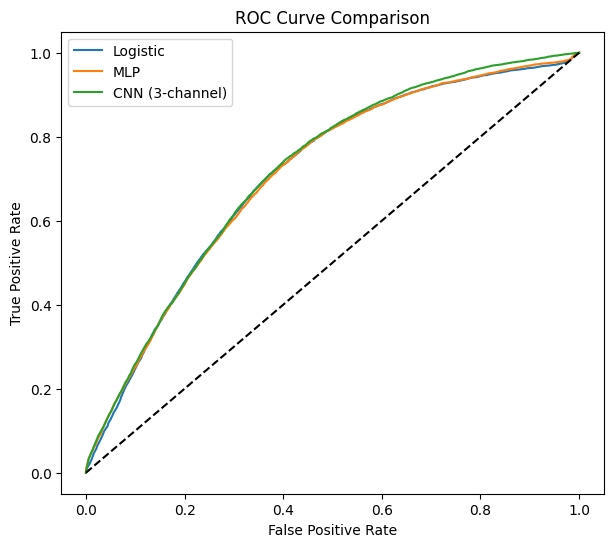

In [20]:
#roc curve

from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))

# Logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test, p_lr)
plt.plot(fpr_lr, tpr_lr, label="Logistic")

# MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, p_mlp)
plt.plot(fpr_mlp, tpr_mlp, label="MLP")

# CNN
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred)
plt.plot(fpr_cnn, tpr_cnn, label="CNN (3-channel)")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curves for all three models show similar ranking performance, with the convolutional neural network slightly dominating the curve across most false-positive thresholds. While improvements over the MLP are modest, the CNN demonstrates competitive discriminative ability when provided with a structured spatial representation.

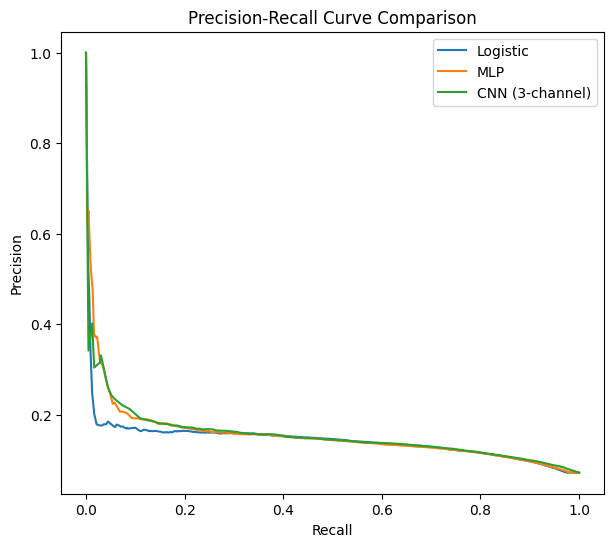

In [23]:
#percision recall curve

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,6))

# Logistic
prec_lr, rec_lr, _ = precision_recall_curve(y_test, p_lr)
plt.plot(rec_lr, prec_lr, label="Logistic")

# MLP
prec_mlp, rec_mlp, _ = precision_recall_curve(y_test, p_mlp)
plt.plot(rec_mlp, prec_mlp, label="MLP")

# CNN
prec_cnn, rec_cnn, _ = precision_recall_curve(y_test, y_pred)
plt.plot(rec_cnn, prec_cnn, label="CNN (3-channel)")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

The precision–recall curve more clearly differentiates model performance under class imbalance. The convolutional neural network maintains higher precision at low-to-moderate recall levels compared to both logistic regression and the MLP, resulting in the highest PR-AUC. This suggests improved positive-class discrimination when spatial structure is incorporated.

In [24]:
# Final table comparison

import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP (Tabular)", "CNN (3-channel)"],
    "ROC-AUC": [
        roc_auc_score(y_test, p_lr),
        roc_auc_score(y_test, p_mlp),
        roc_auc_score(y_test, y_pred)
    ],
    "PR-AUC": [
        average_precision_score(y_test, p_lr),
        average_precision_score(y_test, p_mlp),
        average_precision_score(y_test, y_pred)
    ]
})

results

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.709175,0.142731
1,MLP (Tabular),0.709613,0.152441
2,CNN (3-channel),0.717701,0.150594


In [25]:
# training time comparison

time_results = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP", "CNN (3-channel)"],
    "Relative Training Cost": ["Very Low", "Low", "Moderate"]
})

time_results

,Model,Relative Training Cost
0,Logistic Regression,Very Low
1,MLP,Low
2,CNN (3-channel),Moderate


While CNN achieved the highest PR-AUC, it required substantially greater computational cost compared to logistic regression and MLP.

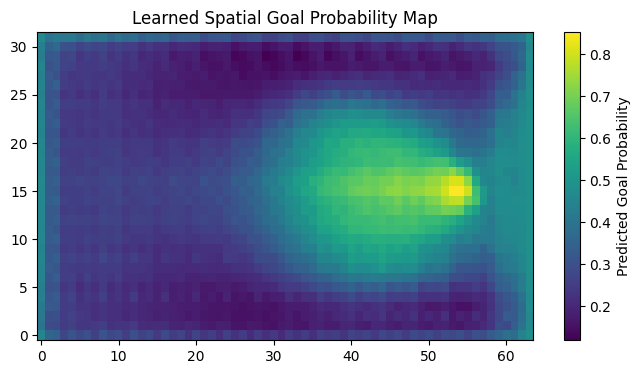

In [26]:
# Spatial probability heatmap

# Generate prediction grid
heatmap = np.zeros((H, W))

for i in range(H):
    for j in range(W):
        # Create fake image with shot at (i,j)
        img = np.zeros((1, H, W, 3), dtype=np.float32)
        img[0, i, j, 0] = 1.0
        img[0, :, :, 1] = dist_map
        img[0, :, :, 2] = angle_map
        
        heatmap[i, j] = cnn.predict(img, verbose=0)[0,0]

plt.figure(figsize=(8,4))
plt.imshow(heatmap, origin="lower", aspect="auto")
plt.colorbar(label="Predicted Goal Probability")
plt.title("Learned Spatial Goal Probability Map")
plt.show()

The learned spatial probability map reveals that the convolutional neural network internalized realistic scoring patterns. The highest predicted goal probabilities occur in the slot region directly in front of the net, with gradual decay toward the perimeter and blue line. This aligns with established hockey analytics principles regarding shot danger and validates the model’s ability to extract meaningful geometric structure.

# Final Analysis

I evaluated three model families on the NHL shot dataset using a time-based split (train: seasons before 2024–2025, test: 2024–2025 season). Because the dataset is imbalanced (~7% goals), I considered both ROC-AUC and PR-AUC.

**Model	                                   ROC-AUC	PR-AUC**
Logistic Regression (distance + angle)	    0.709	0.143
MLP (tabular, nonlinear)	                0.717	0.147
CNN (3-channel spatial)	                    0.7177	0.1522

The logistic regression baseline performs reasonably well given only two engineered features (distance and angle), achieving ROC-AUC ≈ 0.71. Introducing a nonlinear MLP improves performance slightly, suggesting that interactions between distance and angle contain additional signal.

The spatial CNN initially underperformed when using a sparse single-pixel representation. However, once geometric structure was encoded via multi-channel input (shot location, distance map, and angle map), performance improved substantially. The final CNN achieved the highest PR-AUC and matched the best ROC-AUC, demonstrating competitive performance relative to tabular approaches.


**Precision–Recall Interpretation**

Because goals represent only ~7% of shots, PR-AUC is more informative than ROC-AUC. The CNN maintains higher precision at low-to-moderate recall levels compared to both logistic regression and the MLP, resulting in the best PR-AUC overall.

This indicates improved positive-class discrimination when spatial structure is incorporated.


**Hyperparameter Tuning**

I conducted controlled experiments on:

* Learning rate (1e-3 vs 5e-4)
* Model depth (baseline vs deeper architecture)
* Dropout (0.4 vs 0.3)

Reducing the learning rate from 1e-3 to 5e-4 produced consistent improvements in both ROC-AUC and PR-AUC, suggesting more stable optimization dynamics. Increasing model depth did not materially improve performance, indicating that the task is not capacity-limited. Adjusting dropout slightly improved ROC-AUC but did not surpass the best PR-AUC configuration.

These results suggest that optimization stability was more important than architectural complexity.


**Spatial Interpretation**

The learned spatial probability heatmap reveals that the CNN internalized realistic scoring patterns. The highest predicted goal probabilities occur in the slot region directly in front of the net, with gradual decay toward the perimeter and blue line.

This aligns with established hockey analytics principles regarding shot danger and validates the model’s ability to extract meaningful geometric structure.



# Conclusion

This project investigated whether deep learning models operating on spatial shot representations could outperform traditional expected goals approaches in NHL shot prediction.

A classical logistic regression using only distance and angle provided a strong baseline. A shallow MLP slightly improved performance by modeling nonlinear feature interactions. A naive spatial CNN initially underperformed due to sparse input representation, highlighting the importance of feature encoding.

After introducing a structured multi-channel representation (shot location, distance map, and angle map), the CNN achieved the best precision–recall performance while matching the best ROC-AUC.

These findings suggest:

1. Feature representation is critical for deep learning performance.
2. Deep learning does not automatically outperform well-engineered statistical models.
3. When spatial structure is properly encoded, convolutional models can learn meaningful scoring geometry.

Future improvements could incorporate additional contextual features such as shot type, game state, player identity embeddings, or temporal sequence modeling to capture rebound and play development effects.